# 5장 실습 — 액션을 토큰으로 만든다

**대응 이론** 5장 「액션 토크나이저」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 8분)

4장은 질문 하나를 열어 둔 채 끝났다. 미니 VLA를 연속 회귀 헤드로 학습시키면서, 256구간 이산 헤드는 같은 예산에서 수렴하지 못했다고만 적었다. 왜 그런지는 넘겼다.

이 노트북이 그 답을 찾는다. 그리고 답은 예상과 다르다. **이산화가 문제가 아니라 구간 수가 문제다.**

RT-2와 OpenVLA가 액션을 256개 구간으로 잘라 언어 토큰처럼 다루는 방식은 VLA의 출발점이었다. 이 결정에는 대가가 따르고, π0-FAST가 DCT와 BPE를 들고 나온 이유도 거기 있다. 순서대로 짚는다.

1. 왜 액션을 토큰으로 만드는가
2. 구간 수를 바꿔 가며 실제로 학습시킨다 — 4장의 미결 질문
3. 구간을 어디에 놓을 것인가 — 균등과 분위수
4. 진짜 병목은 정밀도가 아니라 토큰 길이다
5. FAST — DCT로 줄이고 BPE로 또 줄인다

In [1]:
%matplotlib inline
import os, math, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib
from scipy.fft import dct, idct

import mini_vla as M          # 4장에서 만든 미니 VLA와 토이 환경

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"

print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.9.1 | threads 10


## 1. 왜 액션을 토큰으로 만드는가

로봇 액션은 실수 벡터다. 그런데 RT-2는 이것을 **정수 번호**로 바꿔 언어 모델에게 던진다. 언뜻 손해 보는 거래처럼 보인다. 정밀도를 버리면서 얻는 것이 무엇인가.

답은 **아무것도 새로 만들지 않아도 된다**는 것이다. 사전학습된 언어 모델은 이미 "다음 토큰을 맞히는" 기계다. 액션을 토큰으로 표현하면 모델 구조도, 손실 함수도, 학습 코드도 그대로 쓸 수 있다. 어휘표 끝에 액션 토큰 256개를 붙이는 것으로 끝난다.

구현은 세 줄이다. `[-1, 1]` 구간을 B개로 자르고 반올림한다.

지시문 : pick up the blue block
액션   : [-0.583 -0.667 -0.593  0.     0.    -0.729 -1.   ]
토큰   : [ 53  42  52 128 128  35   0]
복원   : [-0.584 -0.671 -0.592  0.004  0.004 -0.725 -1.   ]


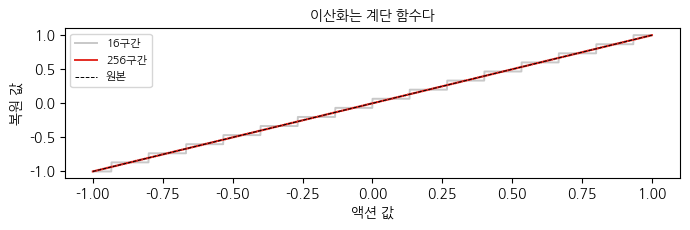

In [2]:
def to_bins(a, B=256):
    return ((a.clamp(-1, 1) + 1) / 2 * (B - 1)).round().long()

def to_action(i, B=256):
    return i.float() / (B - 1) * 2 - 1

im, tk, ac = M.make_dataset(3, 1)
print("지시문 :", M.detok(tk[0]))
print("액션   :", np.round(ac[0].numpy(), 3))
print("토큰   :", to_bins(ac[0]).numpy())
print("복원   :", np.round(to_action(to_bins(ac[0])).numpy(), 3))

xs = torch.linspace(-1, 1, 2000)
plt.figure(figsize=(7, 2.4))
for B, c in [(16, GREY), (256, RED)]:
    plt.plot(xs, to_action(to_bins(xs, B), B), color=c, lw=1.4, label=f"{B}구간")
plt.plot(xs, xs, "k--", lw=.7, label="원본")
plt.legend(fontsize=8); plt.xlabel("액션 값"); plt.ylabel("복원 값")
plt.title("이산화는 계단 함수다", fontsize=10); plt.tight_layout(); plt.show()

## 2. 헤드만 남기고 비교한다

4장의 미결 질문을 풀려면 액션 헤드만 바꿔 가며 성능을 재면 될 것 같다. 실제로 그렇게 해 보면 **결과가 실행할 때마다 뒤집힌다.** 4장의 토이 과제에는 시각과 언어를 결합하는 탐색 문제가 들어 있어서, 모델이 "색 단어 → 해당 블록"이라는 연결을 우연히 찾느냐 마느냐가 성능을 지배한다. 설정을 그대로 두고 시드만 바꿔 세 번 돌리면 각도 오차가 22도에서 85도까지 흔들린다. 액션 헤드의 차이는 그 잡음에 묻힌다.

그래서 지각을 고정한다. 이미지 대신 **장면 상태를 그대로 준다.** 두 블록의 좌표 네 개와 목표 색 원핫 두 개, 합쳐 여섯 개 숫자다. 결합 문제가 사라지고 남는 변수는 하나뿐이다. 액션을 어떻게 표현해서 내보내는가.

재려는 것 하나만 남기고 나머지를 고정하는 것이 실험 설계의 기본이다. 14장에서 평가를 설계할 때 같은 원칙이 다시 나온다.

In [3]:
def make_state_data(n, seed):
    r = np.random.default_rng(seed)
    p = r.uniform(-.8, .8, (n, 2, 2)).astype(np.float32)      # red xy, blue xy
    t = r.integers(0, 2, n)                                    # 목표 색
    x = np.concatenate([p.reshape(n, 4), np.eye(2, dtype=np.float32)[t]], 1)
    c = p[np.arange(n), t]
    d = np.hypot(c[:, 0], c[:, 1])
    a = np.stack([c[:, 0], c[:, 1], -0.15 - 0.5*d, np.zeros(n), np.zeros(n),
                  np.arctan2(c[:, 1], c[:, 0]) / np.pi,
                  np.where(d < .4, 1, -1)], 1).astype(np.float32)
    return torch.from_numpy(x), torch.from_numpy(np.clip(a, -1, 1))

SX, SA = make_state_data(8192, 0)
TX, TA = make_state_data(2048, 7)
AXES = ["dx", "dy", "dz", "roll", "pitch", "yaw", "gripper"]
print("입력", tuple(SX.shape), "-> 액션", tuple(SA.shape))
print("입력 한 줄 :", np.round(SX[0].numpy(), 3), "(red xy, blue xy, 목표 원핫)")
print("액션 한 줄 :", np.round(SA[0].numpy(), 3))

class ActionMLP(nn.Module):
    # head_out=1 이면 연속 회귀, B 이면 B구간 분류
    def __init__(self, head_out, adim=7):
        super().__init__()
        self.head_out, self.adim = head_out, adim
        self.net = nn.Sequential(nn.Linear(6, 128), nn.GELU(),
                                 nn.Linear(128, 128), nn.GELU(),
                                 nn.Linear(128, adim * head_out))
    def forward(self, x):
        y = self.net(x).view(-1, self.adim, self.head_out)
        return y.squeeze(-1) if self.head_out == 1 else y

def fit(bins, seed, steps=1500, bs=128, lr=3e-3):
    torch.manual_seed(seed)
    cont = (bins == 0)
    m = ActionMLP(1 if cont else bins)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(seed + 9)
    for i in range(steps):
        idx = torch.randint(0, len(SX), (bs,), generator=g)
        o, t = m(SX[idx]), SA[idx]
        loss = (F.smooth_l1_loss(o, t, beta=.02) if cont else
                F.cross_entropy(o.reshape(-1, bins), to_bins(t, bins).reshape(-1)))
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    with torch.no_grad():
        o = m(TX)
        return o if cont else to_action(o.argmax(-1), bins)

입력 (8192, 6) -> 액션 (8192, 7)
입력 한 줄 : [ 0.219 -0.368 -0.734 -0.774  1.     0.   ] (red xy, blue xy, 목표 원핫)
액션 한 줄 : [ 0.219 -0.368 -0.364  0.     0.    -0.329 -1.   ]


In [4]:
def metrics(p):
    ang = torch.rad2deg(torch.acos(
        F.cosine_similarity(p[:, :2], TA[:, :2], dim=-1).clamp(-1, 1)))
    return (p - TA).abs().mean().item(), ang.mean().item()

CFG = [(0, "연속 (Huber)"), (4, "이산 4구간"), (16, "이산 16구간"),
       (64, "이산 64구간"), (256, "이산 256구간")]
res, t0 = {}, time.time()
for bins, name in CFG:
    ms = [metrics(fit(bins, s)) for s in (0, 1, 2)]          # 시드 3개
    res[name] = dict(bins=bins,
                     mae=np.mean([m[0] for m in ms]), mae_sp=np.ptp([m[0] for m in ms]),
                     ang=np.mean([m[1] for m in ms]),
                     floor=0 if bins == 0 else 1/(bins-1)/2)
print(f"{'헤드':<14}{'MAE':>9}{'시드편차':>10}{'각도':>9}{'양자화 하한':>13}")
print("-" * 57)
for n, r in res.items():
    print(f"{n:<14}{r['mae']:9.4f}{r['mae_sp']:10.4f}{r['ang']:8.2f}°"
          + (f"{r['floor']:13.4f}" if r['bins'] else f"{'-':>13}"))
print("-" * 57)
print(f"전체 {time.time()-t0:.0f}s.  시드 편차가 작아 이 비교는 믿을 수 있다.")

헤드                  MAE      시드편차       각도       양자화 하한
---------------------------------------------------------
연속 (Huber)       0.0785    0.0037    0.39°            -
이산 4구간           0.1945    0.0013   17.01°       0.1667
이산 16구간          0.0424    0.0007    4.07°       0.0333
이산 64구간          0.0181    0.0016    2.50°       0.0079
이산 256구간         0.0206    0.0022    3.63°       0.0020
---------------------------------------------------------
전체 16s.  시드 편차가 작아 이 비교는 믿을 수 있다.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


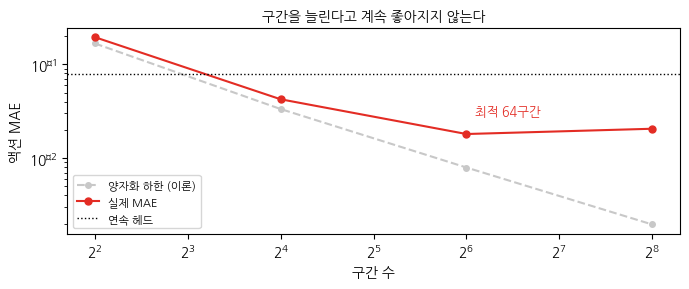

In [14]:
d  = [r for r in res.values() if r["bins"]]
bx = [r["bins"] for r in d]
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(bx, [r["floor"] for r in d], "--", color=GREY, marker="o", ms=4, label="양자화 하한 (이론)")
ax.plot(bx, [r["mae"] for r in d], color=RED, marker="o", ms=5, label="실제 MAE")
ax.axhline(res["연속 (Huber)"]["mae"], color="k", ls=":", lw=1, label="연속 헤드")
best = min(d, key=lambda r: r["mae"])
ax.annotate(f"최적 {best['bins']}구간", (best["bins"], best["mae"]),
            textcoords="offset points", xytext=(6, 14), fontsize=9, color=RED)
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("구간 수"); ax.set_ylabel("액션 MAE")
ax.legend(fontsize=8); ax.set_title("구간을 늘린다고 계속 좋아지지 않는다", fontsize=10)
plt.tight_layout(); plt.show()

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

축                 연속      이산 64구간
-----------------------------------
dx            0.0035       0.0200
dy            0.0035       0.0197
dz            0.0108       0.0116
roll          0.0010       0.0159
pitch         0.0012       0.0159
yaw           0.1166       0.0202   <-
gripper       0.3963       0.0176   <-
-----------------------------------
그리퍼 제외        0.0228       0.0172


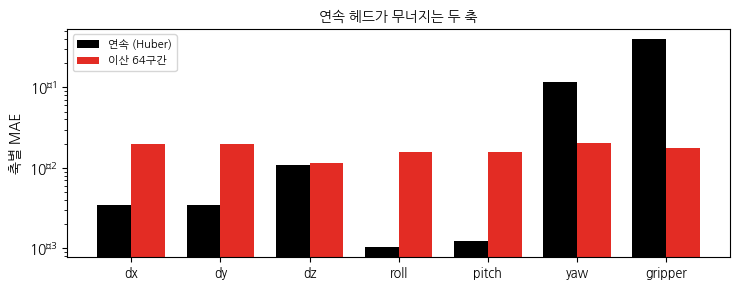

In [15]:
pc, pd = fit(0, 0), fit(64, 0)
ec, ed = (pc - TA).abs().mean(0), (pd - TA).abs().mean(0)
print(f"{'축':<10}{'연속':>10}{'이산 64구간':>13}")
print("-" * 35)
for i, n in enumerate(AXES):
    print(f"{n:<10}{ec[i]:10.4f}{ed[i]:13.4f}" + ("   <-" if ec[i] > 5*ed[i] else ""))
print("-" * 35)
print(f"{'그리퍼 제외':<10}{ec[:6].mean():10.4f}{ed[:6].mean():13.4f}")

fig, ax = plt.subplots(figsize=(7.5, 3))
w, xs = .38, np.arange(len(AXES))
ax.bar(xs - w/2, ec.numpy(), w, color="k", label="연속 (Huber)")
ax.bar(xs + w/2, ed.numpy(), w, color=RED, label="이산 64구간")
ax.set_xticks(xs); ax.set_xticklabels(AXES, fontsize=9)
ax.set_yscale("log"); ax.set_ylabel("축별 MAE")
ax.legend(fontsize=8); ax.set_title("연속 헤드가 무너지는 두 축", fontsize=10)
plt.tight_layout(); plt.show()

In [7]:
dist = torch.hypot(TA[:, 0], TA[:, 1])           # 목표까지 거리 (경계는 0.4)
print(f"{'거리 구간':<14}{'정답':>8}{'연속 예측':>12}{'이산 예측':>12}{'샘플':>8}")
print("-" * 56)
for lo, hi in [(0, .3), (.3, .5), (.5, 1.2)]:
    m_ = (dist >= lo) & (dist < hi)
    print(f"|d| {lo}~{hi}    {TA[m_,6].mean():8.2f}{pc[m_,6].mean():12.2f}"
          f"{pd[m_,6].mean():12.2f}{int(m_.sum()):8d}")
print("-" * 56)
close_rate = (TA[:, 6] > 0).float().mean().item()
print(f"정답 분포        닫기(+1) {close_rate:.0%}   열기(-1) {1-close_rate:.0%}")
print(f"부호 정확도      연속 {((pc[:,6]>0)==(TA[:,6]>0)).float().mean():.0%}"
      f"   이산 {((pd[:,6]>0)==(TA[:,6]>0)).float().mean():.0%}")

거리 구간               정답       연속 예측       이산 예측      샘플
--------------------------------------------------------
|d| 0~0.3        1.00       -0.92        1.00     225
|d| 0.3~0.5       -0.15       -0.95       -0.14     428
|d| 0.5~1.2       -1.00       -1.00       -1.00    1395
--------------------------------------------------------
정답 분포        닫기(+1) 20%   열기(-1) 80%
부호 정확도      연속 80%   이산 99%


## 3. 구간을 어디에 놓을 것인가

지금까지는 `[-1, 1]`을 **균등하게** 잘랐다. 실제 로봇 액션이 그 구간에 고르게 퍼져 있다면 합리적이다. 그렇지 않다.

실제 조작 데이터의 delta 액션은 대부분 0 근처에 몰려 있다. 팔은 대체로 조금씩 움직이고, 크게 움직이는 순간은 드물다. 아래에서 최소 저크 궤적으로 그런 분포를 만들어 확인한다. 여기서 만드는 청크 데이터는 4절과 5절에서도 계속 쓴다.

청크셋 (2000, 50, 7)
delta 액션 분위수 p1/p25/p50/p75/p99: [-0.8   -0.058  0.     0.059  0.801]
|값| < 0.1 인 비율 61%


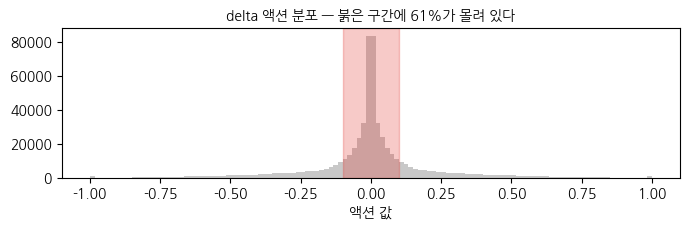

In [8]:
H, AD = 50, 7        # 청크 길이 50 스텝, 7-DoF

def _minjerk(n, a, b):
    t = np.linspace(0, 1, n)[:, None]
    return a + (b - a) * (10*t**3 - 15*t**4 + 6*t**5)

def make_chunk(rng):
    wp = rng.uniform(-1, 1, (3, AD)); wp[:, 3:5] *= 0.15      # roll/pitch 는 거의 안 움직인다
    pos = np.concatenate([_minjerk(H//2 + 1, wp[0], wp[1]),
                          _minjerk(H - H//2, wp[1], wp[2])])
    d = np.diff(pos, axis=0) * 8.0                            # 위치 차분 -> delta 액션
    d[:, 6] = np.where(np.arange(H) < H * rng.uniform(.3, .7), -1, 1)   # 그리퍼는 이산
    return np.clip(d + rng.normal(0, .004, d.shape), -1, 1).astype(np.float32)

rng = np.random.default_rng(0)
D = np.stack([make_chunk(rng) for _ in range(2000)])
mv = D[:, :, :6]
print("청크셋", D.shape)
print("delta 액션 분위수 p1/p25/p50/p75/p99:", np.round(np.percentile(mv, [1,25,50,75,99]), 3))
print(f"|값| < 0.1 인 비율 {100*(np.abs(mv) < .1).mean():.0f}%")

plt.figure(figsize=(7, 2.4))
plt.hist(mv.reshape(-1), bins=120, range=(-1, 1), color=GREY)
plt.axvspan(-.1, .1, color=RED, alpha=.25)
plt.title("delta 액션 분포 — 붉은 구간에 61%가 몰려 있다", fontsize=10)
plt.xlabel("액션 값"); plt.tight_layout(); plt.show()

                          균등         분위수
----------------------------------------
전체 MAE               0.00181     0.00180
|a|<0.1 MAE          0.00195     0.00032
----------------------------------------
작은 액션에서 6.1배 정확하다.


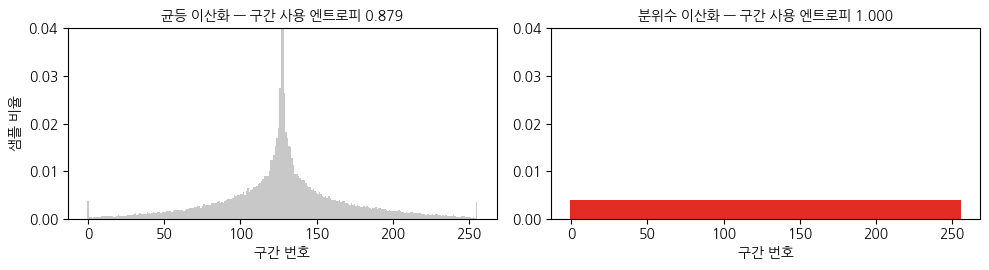

In [9]:
B = 256
edges = np.quantile(D.reshape(-1, AD), np.linspace(0, 1, B + 1), axis=0)
centres = (edges[:-1] + edges[1:]) / 2

def q_bins(x):
    return np.stack([np.clip(np.searchsorted(edges[1:-1, d], x[..., d]), 0, B-1)
                     for d in range(AD)], -1)
def q_action(i):
    return np.stack([centres[i[..., d], d] for d in range(AD)], -1)

def u_bins(x):  return np.clip(((x + 1) / 2 * (B - 1)).round(), 0, B - 1).astype(int)
def u_action(i): return i / (B - 1) * 2 - 1

Ru, Rq = u_action(u_bins(D)), q_action(q_bins(D))
small = np.abs(D) < 0.1
print(f"{'':16}{'균등':>12}{'분위수':>12}")
print("-" * 40)
print(f"{'전체 MAE':16}{np.abs(Ru-D).mean():12.5f}{np.abs(Rq-D).mean():12.5f}")
print(f"{'|a|<0.1 MAE':16}{np.abs(Ru-D)[small].mean():12.5f}{np.abs(Rq-D)[small].mean():12.5f}")
print("-" * 40)
print(f"작은 액션에서 {np.abs(Ru-D)[small].mean()/np.abs(Rq-D)[small].mean():.1f}배 정확하다.")

fig, ax = plt.subplots(1, 2, figsize=(10, 2.8))
for a, idx, t in zip(ax, [u_bins(D), q_bins(D)], ["균등 이산화", "분위수 이산화"]):
    h = np.bincount(idx[:, :, 0].reshape(-1), minlength=B) / idx[:, :, 0].size
    a.bar(range(B), h, width=1.0, color=RED if "분위수" in t else GREY)
    ent = -(h[h > 0] * np.log(h[h > 0])).sum() / np.log(B)
    a.set_title(f"{t} — 구간 사용 엔트로피 {ent:.3f}", fontsize=10)
    a.set_xlabel("구간 번호"); a.set_ylim(0, .04)
ax[0].set_ylabel("샘플 비율")
plt.tight_layout(); plt.show()

## 4. 진짜 병목 — 토큰 길이

지금까지는 액션 **한 스텝**을 다뤘다. 실제 VLA는 한 번에 여러 스텝을 내보낸다. 4장에서 언급한 액션 청킹이고, 3장의 ACT가 처음 제안한 방식이다. 매 스텝 추론하는 대신 50스텝을 한꺼번에 뽑으면 추론 횟수가 50분의 1이 된다.

그런데 이산 토큰 방식에서 청킹은 **토큰 수를 그대로 곱한다.**

In [10]:
for h in [1, 10, 50]:
    print(f"청크 {h:2d}스텝 x 7축 = {h*AD:3d} 토큰"
          + ("   <- 한 스텝만 예측" if h == 1 else ""))

step_ms = 12
print(f"\n자기회귀 디코딩은 토큰 하나에 한 번씩 forward 한다.")
print(f"토큰당 {step_ms}ms 라 가정하면:")
for h in [1, 10, 50]:
    t = h * AD * step_ms
    print(f"  {h:2d}스텝 청크 -> {h*AD:3d} 토큰 -> {t:5d}ms -> 청크당 {1000/t:5.1f} Hz"
          f"  (스텝당 {1000/(t/h):6.1f} Hz)")
print("\n청킹은 스텝당 처리량을 살리지만, 한 번의 지연이 통째로 커진다.")
print("로봇이 다음 청크를 받기까지 4초를 기다린다면 반응성은 이미 죽어 있다.")

청크  1스텝 x 7축 =   7 토큰   <- 한 스텝만 예측
청크 10스텝 x 7축 =  70 토큰
청크 50스텝 x 7축 = 350 토큰

자기회귀 디코딩은 토큰 하나에 한 번씩 forward 한다.
토큰당 12ms 라 가정하면:
   1스텝 청크 ->   7 토큰 ->    84ms -> 청크당  11.9 Hz  (스텝당   11.9 Hz)
  10스텝 청크 ->  70 토큰 ->   840ms -> 청크당   1.2 Hz  (스텝당   11.9 Hz)
  50스텝 청크 -> 350 토큰 ->  4200ms -> 청크당   0.2 Hz  (스텝당   11.9 Hz)

청킹은 스텝당 처리량을 살리지만, 한 번의 지연이 통째로 커진다.
로봇이 다음 청크를 받기까지 4초를 기다린다면 반응성은 이미 죽어 있다.


## 5. FAST — DCT로 줄이고 BPE로 또 줄인다

압축의 실마리는 **로봇 궤적이 매끄럽다**는 데 있다. 인접한 스텝의 액션은 서로 비슷하므로 350개 숫자에는 중복이 많다. 매끄러운 신호를 몇 개의 주파수 성분으로 표현하는 도구가 이산 코사인 변환이고, JPEG이 이미지에 쓰는 것과 같은 변환이다.

50스텝 궤적을 DCT로 옮기면 에너지가 낮은 주파수 몇 개에 몰린다. 나머지를 버려도 원래 궤적이 거의 복원된다.

DCT 계수 유지 개수별 재구성 오차
  상위  4개 유지 ( 28 값,   8%)  MAE 0.08850
  상위  8개 유지 ( 56 값,  16%)  MAE 0.02599
  상위 16개 유지 (112 값,  32%)  MAE 0.01379
  상위 32개 유지 (224 값,  64%)  MAE 0.00830
  상위 50개 유지 (350 값, 100%)  MAE 0.00000


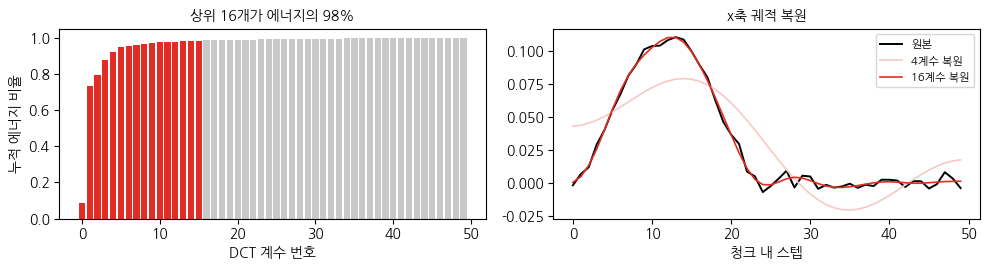

In [11]:
Cf = dct(D, axis=1, norm="ortho")
energy = (Cf**2).mean((0, 2)); energy /= energy.sum()
print("DCT 계수 유지 개수별 재구성 오차")
keep_list, errs = [4, 8, 16, 32, 50], []
for k in keep_list:
    c = Cf.copy(); c[:, k:, :] = 0
    e = np.abs(idct(c, axis=1, norm="ortho") - D).mean(); errs.append(e)
    print(f"  상위 {k:2d}개 유지 ({k*AD:3d} 값, {100*k/H:3.0f}%)  MAE {e:.5f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 2.8))
ax[0].bar(range(H), np.cumsum(energy), color=GREY)
ax[0].bar(range(16), np.cumsum(energy)[:16], color=RED)
ax[0].set_xlabel("DCT 계수 번호"); ax[0].set_ylabel("누적 에너지 비율")
ax[0].set_title(f"상위 16개가 에너지의 {100*np.cumsum(energy)[15]:.0f}%", fontsize=10)
i = 0
ax[1].plot(D[i, :, 0], color="k", lw=1.4, label="원본")
for k, c in [(4, PINK), (16, RED)]:
    cc = Cf[i:i+1].copy(); cc[:, k:, :] = 0
    ax[1].plot(idct(cc, axis=1, norm="ortho")[0, :, 0], color=c, lw=1.2, label=f"{k}계수 복원")
ax[1].legend(fontsize=8); ax[1].set_xlabel("청크 내 스텝"); ax[1].set_title("x축 궤적 복원", fontsize=10)
plt.tight_layout(); plt.show()

양자화 DCT (2000, 16, 7)  |  값이 0인 비율 38.2%
BPE 병합 123개 학습 (1s)

원본 350 토큰 -> DCT16 112 토큰 -> BPE 65 토큰
총 5배 압축.  자기ођу회귀 디코딩 시간도 그만큼 줄어든다.


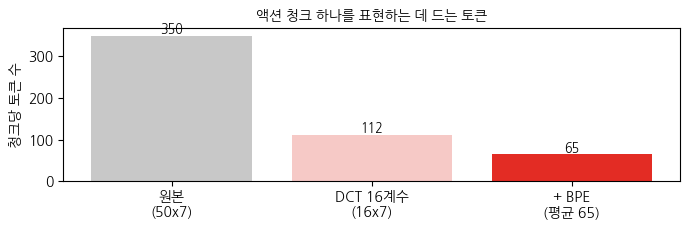

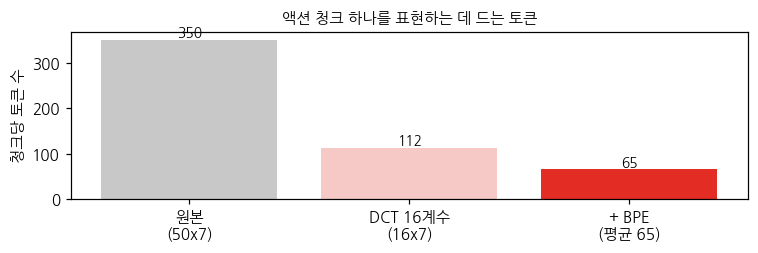

In [12]:
def quantise_dct(X, k=16, scale=40):
    c = dct(X, axis=1, norm="ortho")[:, :k, :]
    return np.clip(np.round(c * scale), -127, 127).astype(np.int16)

Q = quantise_dct(D)
print(f"양자화 DCT {Q.shape}  |  값이 0인 비율 {100*(Q == 0).mean():.1f}%")

def learn_bpe(seqs, n_merges=400, min_count=20):
    seqs = [list(s) for s in seqs]; nxt, table = 1000, {}
    for _ in range(n_merges):
        cnt = {}
        for s in seqs:
            for a, b in zip(s, s[1:]):
                cnt[(a, b)] = cnt.get((a, b), 0) + 1
        if not cnt: break
        pair, c = max(cnt.items(), key=lambda kv: kv[1])
        if c < min_count: break
        table[pair] = nxt
        for i, s in enumerate(seqs):
            o, j = [], 0
            while j < len(s):
                if j < len(s)-1 and (s[j], s[j+1]) == pair: o.append(nxt); j += 2
                else: o.append(s[j]); j += 1
            seqs[i] = o
        nxt += 1
    return table, seqs

seqs = [q.reshape(-1).tolist() for q in Q[:400]]
t0 = time.time(); table, encoded = learn_bpe(seqs)
avg = float(np.mean([len(s) for s in encoded]))
print(f"BPE 병합 {len(table)}개 학습 ({time.time()-t0:.0f}s)")
print(f"\n원본 {H*AD} 토큰 -> DCT16 {Q.shape[1]*AD} 토큰 -> BPE {avg:.0f} 토큰")
print(f"총 {H*AD/avg:.0f}배 압축.  자기ођу회귀 디코딩 시간도 그만큼 줄어든다.")

plt.figure(figsize=(7, 2.4))
labels = ["원본\n(50x7)", f"DCT 16계수\n({Q.shape[1]}x7)", f"+ BPE\n(평균 {avg:.0f})"]
vals = [H*AD, Q.shape[1]*AD, avg]
plt.bar(labels, vals, color=[GREY, PINK, RED])
for i, v in enumerate(vals): plt.text(i, v + 6, f"{v:.0f}", ha="center", fontsize=9)
plt.ylabel("청크당 토큰 수"); plt.title("액션 청크 하나를 표현하는 데 드는 토큰", fontsize=10)
plt.tight_layout(); plt.show()

### 다음 장으로

압축은 이산 토큰이라는 틀 안에서의 최적화다. 틀 자체를 버리는 선택지가 남아 있다. 액션 청크 전체를 한 번의 forward로 뽑아 자기회귀 디코딩을 없애는 방식이며, π0의 플로 매칭이 그것이다. 6장에서 직접 만든다.